# Comparison between installed capacities in Denmark 2025
### This notebook aims to compare the installed electricities in Denmark 2025, using the powerplantmatching dataset, data from Energistyrelsen and the output of the network model generated from PyPSA-eur.


First load the data from the csv files and network file

In [ ]:
import pandas as pd
import pypsa
from pathlib import Path

# The notebook is located in the "notebooks" directory
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT_DIR / "data"
NET_DIR = DATA_DIR / "networks"

# Load powerplant data
df_ens = pd.read_csv(DATA_DIR / "powerplants.csv")
df_ppm = pd.read_csv(DATA_DIR / "powerplants_PPM.csv")

# Raw Energistyrelsen data
df_ens_pp = pd.read_csv(
        DATA_DIR / "ENS_power_plant_register.csv",
        sep=";",
        decimal=",",
    )

# Load network
OG_network = pypsa.Network(NET_DIR / "base_s_3_OG.nc") # Original from powerplantmatching
OGI_network = pypsa.Network(NET_DIR / "base_s_3_OG_Irena.nc") # Original from powerplantmatching + IRENA
ENS_network = pypsa.Network(NET_DIR / "base_s_3_updated_PPM.nc") # Data from Energistyrelsen
EXT_network = pypsa.Network(NET_DIR / "base_s_3_extended.nc") # Extended network

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


Lets compare the different technologies capacities installed with the ENS and PPM dataset 

Installed capacities per fueltype in Denmark active in 2025 [MW]:
                      ENS     PPM
Fueltype                         
Biogas          116.23600     0.0
Hard Coal       385.00000   716.0
Hydro             6.93900     0.0
Natural Gas    1780.21200  1461.2
Oil             732.61000   126.0
Solar          5068.32368  3364.9
Solid Biomass  1883.62800  1781.0
Waste           388.09000   153.0
Wind           7499.92134  4609.4


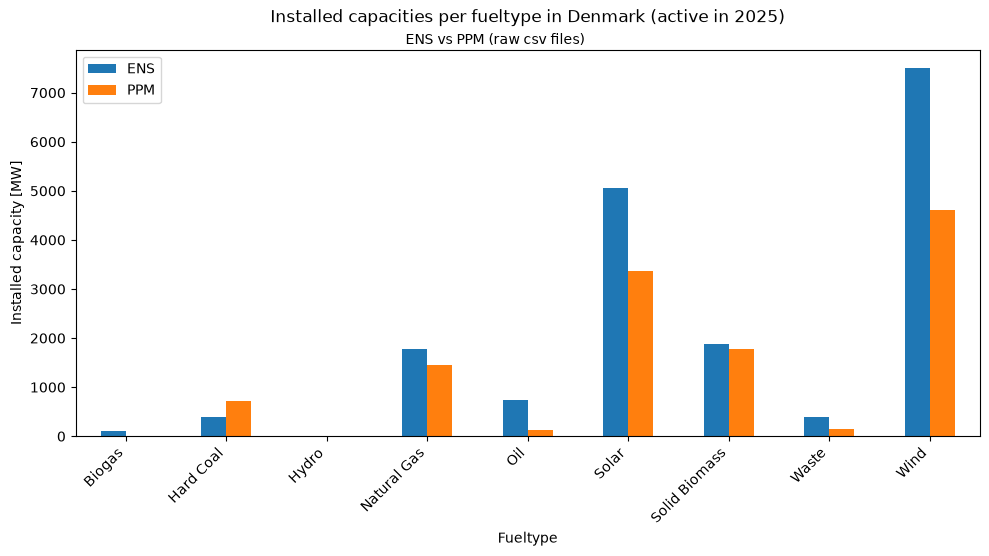

In [2]:
import matplotlib.pyplot as plt

YEAR = 2025


def active_in_year(df, year):
    is_dk = df["Country"] == "Denmark"
    is_in = df["DateIn"] <= year
    is_not_out = df["DateOut"].isna() | (df["DateOut"] >= year)
    return df.loc[is_dk & is_in & is_not_out]


df_ens_dk = active_in_year(df_ens, YEAR)
df_ppm_dk = active_in_year(df_ppm, YEAR)

cap_ens = df_ens_dk.groupby("Fueltype")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Fueltype")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per fueltype in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per fueltype in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Installed capacities per technology in Denmark active in 2025 [MW]:
                          ENS     PPM
Technology                           
CCGT                855.94000   711.2
Combustion Engine  1016.65600     0.0
OCGT                351.10000     0.0
Offshore           2598.50004  2652.6
Onshore            4879.76300  1956.8
PV                 5068.32368  3359.4
Run-Of-River          6.93900     0.0
Steam Turbine      3057.13000  1672.0
Csp                   0.00000     5.5


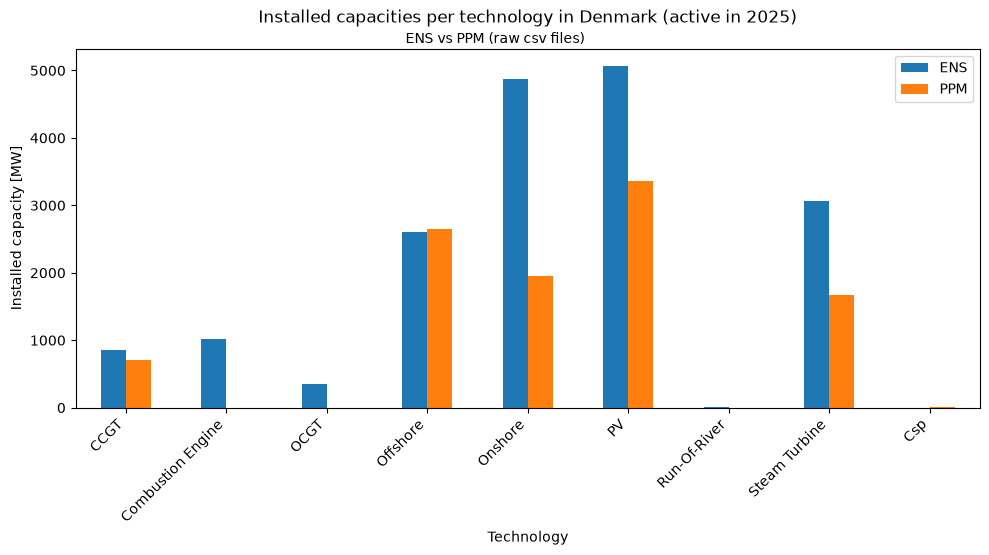

In [3]:
cap_ens = df_ens_dk.groupby("Technology")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Technology")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per technology in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per technology in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Comparing different network files
Now we can look further into the generated network files with different input data and config files from PyPSA-Eur

In [ ]:
def dk_ac_capacity_by_carrier(network):
    dk_ac_buses = network.buses.index[
        network.buses["carrier"].isin(["AC", "DC"])
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus1"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    components = pd.concat([gens, storage, links])
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ens_ac = dk_ac_capacity_by_carrier(ENS_network)

cap_ext_ac = dk_ac_capacity_by_carrier(EXT_network)

# Compare the AC capacities for Denmark between the original and Energistyrelsen networks
df_el = pd.DataFrame({
    "Energistyrelsen Normal": cap_ens_ac,
    "Energistyrelsen Extended": cap_ext_ac
})
df_el



,PPM Network,Energistyrelsen Network
carrier,,
CCGT,0.060456,0.088699
DC,1880.000000,1880.000000
OCGT,386.121031,1052.216063
biomass,0.046184,0.095883
coal,0.043719,0.062281
electricity distribution grid,4902.339021,5216.926120
lignite,0.052725,0.076184
nuclear,0.005247,0.008598
offwind-ac,2652.600000,2574.900040


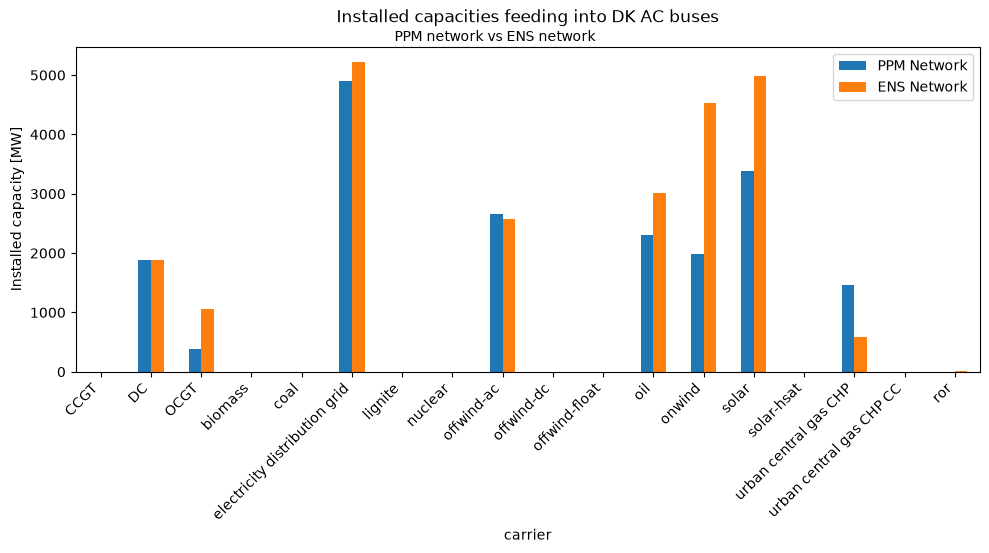

In [5]:
ac_comparison = pd.concat(
    [cap_ppm_ac, cap_ens_ac], axis=1, keys=["PPM Network", "ENS Network"]
).fillna(0)

ac_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK AC buses", y=1.05)
plt.suptitle("PPM network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [6]:
def dk_heat_capacity_by_carrier(network):
    dk_heat_buses = network.buses.index[
        network.buses["carrier"].str.contains("heat", case=False, na=False)
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus1"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    components = pd.concat([gens, storage, links])
    
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ppm_heat = dk_heat_capacity_by_carrier(OG_network)

cap_ens_heat = dk_heat_capacity_by_carrier(ENS_network)

# Compare the heat capacities for Denmark between the original and Energistyrelsen networks
df_heat = pd.DataFrame({
    "Original Network": cap_ppm_heat,
    "Energistyrelsen Network": cap_ens_heat
})
df_heat


,Original Network,Energistyrelsen Network
carrier,,
rural biomass boiler,528.767676,456.836658
rural gas boiler,339.672696,366.199544
rural heat vent,0.042619,5.202815
rural resistive heater,52.670027,74.254514
rural solar thermal,0.069489,0.110353
rural water tanks discharger,1.865843,3.168449
urban central gas boiler,8193.670184,8323.825219
urban central heat vent,0.018019,0.781587
urban central resistive heater,0.248471,335.987433


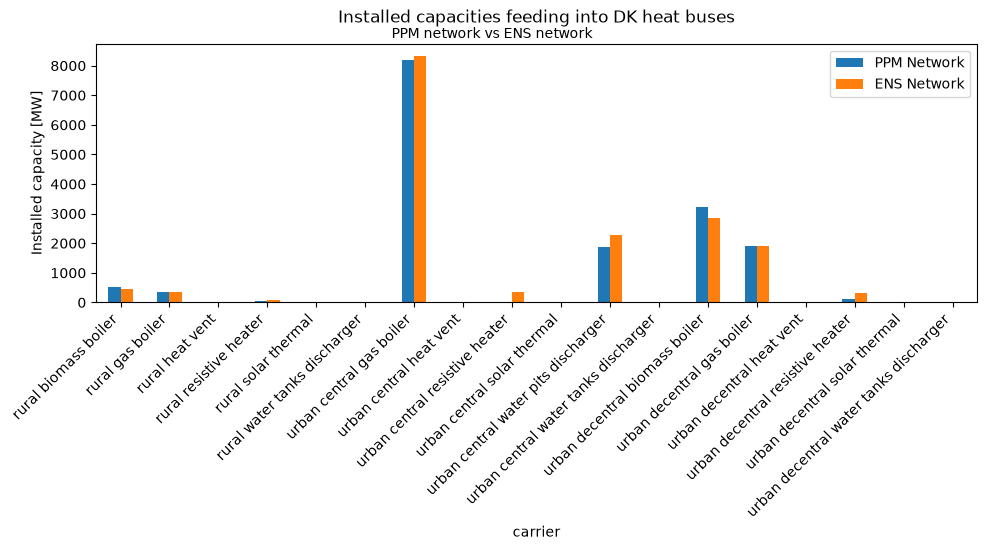

In [7]:
heat_comparison = pd.concat(
    [cap_ppm_heat, cap_ens_heat], axis=1, keys=["PPM Network", "ENS Network"]
).fillna(0)

heat_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK heat buses", y=1.05)
plt.suptitle("PPM network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [8]:
# Check total heat capacity of installed heat from df_ens_pp active in 2025


total_heat_capacity = df_ens_pp["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from Energistyrelsen data: {total_heat_capacity} MW')

# check how much of it is from combined heat and power (CHP) plants
chp_heat_capacity = df_ens_pp[df_ens_pp["elkapacitet_MW"] > 0]["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from CHP plants: {chp_heat_capacity} MW')

chp_power_capacity = df_ens_pp[(df_ens_pp["elkapacitet_MW"] > 0) & (df_ens_pp["varmekapacitet_MW"] > 0)]["elkapacitet_MW"].sum()
print(f'Total installed power capacity from CHP plants: {chp_power_capacity} MW')

# chp_power + chp_heat gives the total installed capacity of CHP plants
total_chp_capacity = chp_power_capacity + chp_heat_capacity
print(f'Total installed capacity from CHP plants: {total_chp_capacity} MW')

Total installed heat capacity from Energistyrelsen data: 26507.5246 MW
Total installed heat capacity from CHP plants: 9507.455600000001 MW
Total installed power capacity from CHP plants: 6500.142 MW
Total installed capacity from CHP plants: 16007.597600000001 MW


In [9]:
# sum df heat energistyrelsen 
sum_network_ens = df_heat['Energistyrelsen Network'].sum()

In [10]:
# check all anlaegtype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0]["anlaegstype_navn"].unique()

# sum for each anlaegstype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0].groupby("anlaegstype_navn")["varmekapacitet_MW"].sum()

anlaegstype_navn
Anden                           12.5000
Bioforgasn. m. FM               41.5600
Bioforgasn. m. KE                5.5000
Dampkedel                       44.0000
Dampturbine                   6735.5700
Elpatron                      2128.4950
Forbrændingsmotor             1208.8156
Gasturbine                     403.2000
Geotermi                        32.3000
Kedel                        12525.7920
Kombianlæg                    1081.6000
Nødstrømsanlæg                   2.5900
Organic Rankine (ORC)           34.0000
Overskudsvarme                 348.9450
Solvarme                      1099.9040
Stirlingmotor                    0.1200
Varmepumpe                      18.4410
Varmepumpe Anden                33.7560
Varmepumpe Grundvand            15.9680
Varmepumpe Havvand              35.0000
Varmepumpe Kombi                10.6000
Varmepumpe Luft                464.2870
Varmepumpe Overskudsvarme      111.3230
Varmepumpe Solvarme             17.8380
Varmepumpe Spildevand  

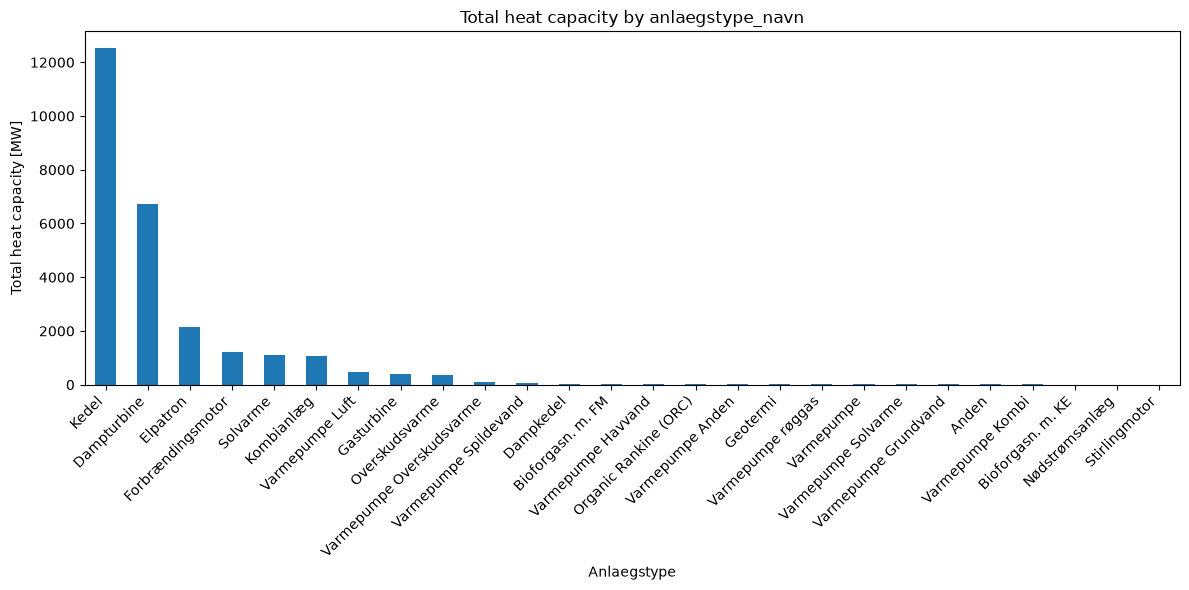

In [11]:
heat_capacity_by_type = (
    df_ens_pp.loc[df_ens_pp["varmekapacitet_MW"] > 0]
    .groupby("anlaegstype_navn")["varmekapacitet_MW"]
    .sum()
    .sort_values(ascending=False)
)

ax = heat_capacity_by_type.plot(kind="bar", figsize=(12, 6))
ax.set_xlabel("Anlaegstype")
ax.set_ylabel("Total heat capacity [MW]")
ax.set_title("Total heat capacity by anlaegstype_navn")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# print all buses for Denmark in ENS network
ens_dk_buses = ENS_network.buses.index[ENS_network.buses["country"] == "DK"]
ENS_network.buses.loc[ens_dk_buses]

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country,substation_lv,substation_off
name,,,,,,,,,,,,,,,,
DK0 0AC,380.0,,12.303248,55.515979,AC,MWh_el,DK0 0AC,1.0,0.0,inf,PQ,,0,DK,1.0,1.0
DK1 0AC,380.0,,9.728013,56.142467,AC,MWh_el,DK1 0AC,1.0,0.0,inf,Slack,,1,DK,1.0,1.0
DK0 0AC co2 stored,1.0,,12.303248,55.515979,co2 stored,t_co2,DK0 0AC,1.0,0.0,inf,PQ,,4,DK,NaN,NaN
DK1 0AC co2 stored,1.0,,9.728013,56.142467,co2 stored,t_co2,DK1 0AC,1.0,0.0,inf,PQ,,5,DK,NaN,NaN
DK0 0AC co2 sequestered,1.0,,12.303248,55.515979,co2 sequestered,t_co2,DK0 0AC,1.0,0.0,inf,PQ,,7,DK,NaN,NaN
DK1 0AC co2 sequestered,1.0,,9.728013,56.142467,co2 sequestered,t_co2,DK1 0AC,1.0,0.0,inf,PQ,,8,DK,NaN,NaN
DK0 0AC gas,1.0,,12.303248,55.515979,gas,MWh_LHV,DK0 0AC,1.0,0.0,inf,PQ,,10,DK,NaN,NaN
DK1 0AC gas,1.0,,9.728013,56.142467,gas,MWh_LHV,DK1 0AC,1.0,0.0,inf,PQ,,11,DK,NaN,NaN
DK0 0AC solid biomass,1.0,,12.303248,55.515979,biomass,MWh_th,DK0 0AC,1.0,0.0,inf,PQ,,18,DK,NaN,NaN
